# Import

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# np.set_printoptions(threshold=np.inf)

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

# - dirs 
from ciim.src.common import mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets_e, datasets_all, datasets_a, palette_datasets, palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types

from ciim.src.tf_activity.helper import retrieve_feature_data, retrieve_adata, retrieve_net, calculate_tf_activity, retrieve_sig_stats
from ciim.src.tf_activity.plots import  plot_net_nx, plot_trend_tfs

from ciim.src.utils.plots import dotplot

# Pseudocell

In [2]:
adata = ad.read_h5ad('/vol/projects/jnourisa/datasets/CXCL9_sc.h5ad')
adata = adata[ ~adata.obs.isna().any(axis=1), :]

In [ ]:
# - group by before metacells
cols = ['cell_type', 'dataset', 'donor_id', 'age', 'treatment']
available_cols = [col for col in cols if col in adata.obs.columns]

adata.obs['groupby_col'] = adata.obs[available_cols].astype(str).agg('_'.join, axis=1)

In [16]:
7*11*5

385

In [19]:
print(adata.obs['groupby_col'].value_counts())
# adata.obs['groupby_col'].nunique()

groupby_col
CD4T_CXCL9_TI_CXCL9_TI_D_25.0_24 h rhIFN-γ                           2560
CD8T_CXCL9_TI_CXCL9_TI_B_28.0_24 h LPS + metformin + ruxolitinib     2021
CD4T_CXCL9_TI_CXCL9_TI_D_25.0_24 h RPMI + metformin                  2002
CD4T_CXCL9_TI_CXCL9_TI_C_31.0_24 h LPS + metformin + ruxolitinib     2000
CD4T_CXCL9_TI_CXCL9_TI_F_30.0_24 h RPMI + metformin + ruxolitinib    1889
                                                                     ... 
MONO_CXCL9_TI_CXCL9_TI_C_31.0_24 h RPMI + metformin                   127
MONO_CXCL9_TI_CXCL9_TI_C_31.0_24 h RPMI                               126
NK_CXCL9_TI_CXCL9_TI_D_25.0_0 h Unstimulated                          121
B_CXCL9_TI_CXCL9_TI_C_31.0_24 h rhIFN-γ                               115
MONO_CXCL9_TI_CXCL9_TI_C_31.0_24 h rhCXCL9                            107
Name: count, Length: 385, dtype: int64


In [20]:
def assign_metacells(df, groupby_col, metacell_size=15):
    df = df.copy()
    metacell_id = np.empty(len(df), dtype=object)

    # Create a Series of indices to preserve order
    for group in df[groupby_col].unique():
        mask = df[groupby_col] == group
        idx = np.flatnonzero(mask)
        n_metacells = int(np.ceil(len(idx) / metacell_size))
        ids = np.repeat([f"{group}_MC{i}" for i in range(n_metacells)], metacell_size)[:len(idx)]
        metacell_id[idx] = ids

    df['metacell_id'] = metacell_id
    return df
adata.obs = assign_metacells(adata.obs, groupby_col='groupby_col', metacell_size=15)
adata.obs.head()[['groupby_col','metacell_id']]

,groupby_col,metacell_id
pool-AG1_AAACCAAAGCGACTAC-1,CD4T_CXCL9_TI_CXCL9_TI_E_29.0_24 h RPMI + metf...,CD4T_CXCL9_TI_CXCL9_TI_E_29.0_24 h RPMI + metf...
pool-AG1_AAACCAAAGCTTAGAT-1,MONO_CXCL9_TI_CXCL9_TI_C_31.0_24 h RPMI + metf...,MONO_CXCL9_TI_CXCL9_TI_C_31.0_24 h RPMI + metf...
pool-AG1_AAACCAAAGTTAACCG-1,NK_CXCL9_TI_CXCL9_TI_C_31.0_24 h RPMI + metformin,NK_CXCL9_TI_CXCL9_TI_C_31.0_24 h RPMI + metfor...
pool-AG1_AAACCATTCACAGAGG-1,CD4T_CXCL9_TI_CXCL9_TI_C_31.0_24 h RPMI + metf...,CD4T_CXCL9_TI_CXCL9_TI_C_31.0_24 h RPMI + metf...
pool-AG1_AAACCATTCCATCCAT-1,CD4T_CXCL9_TI_CXCL9_TI_E_29.0_24 h RPMI + metf...,CD4T_CXCL9_TI_CXCL9_TI_E_29.0_24 h RPMI + metf...


In [21]:
from task_grn_inference.src.utils.util import sum_by

def normalize(adata):
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    return adata
def bulkify_main(adata, sum_by_col):
    adata.obs[sum_by_col] = adata.obs[sum_by_col].astype('category')
    print(adata.obs[sum_by_col].nunique())
    adata_bulk = sum_by(adata, sum_by_col, unique_mapping=True)
    adata_bulk = normalize(adata_bulk)

    # merge the remaining metadata
    adata_bulk.obs['__original_index__'] = adata_bulk.obs.index
    merged_obs = adata_bulk.obs.merge(
        adata.obs,
        on=sum_by_col,
        how='left',
        suffixes=('', '_from_single')
    )
    merged_obs = merged_obs.drop_duplicates(subset=sum_by_col, keep='last')
    merged_obs = merged_obs.set_index('__original_index__').loc[adata_bulk.obs.index]
    adata_bulk.obs = merged_obs
    return adata_bulk
adata_metacell = bulkify_main(adata, sum_by_col='metacell_id')

16396


In [22]:
# - save
adata_metacell.obs = adata_metacell.obs[['dataset', 'sex', 'donor_id', 'age', 'treatment', 'cell_type']]
adata_metacell.write('/vol/projects/jnourisa/datasets/CXCL9_metacell.h5ad')

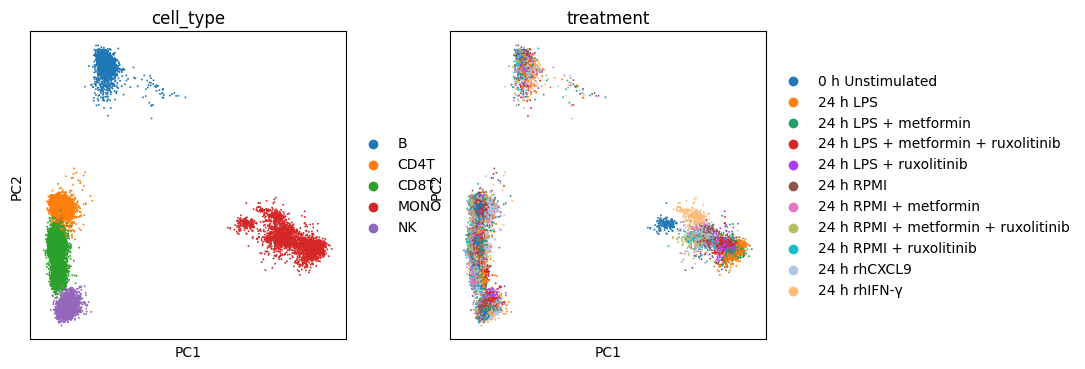

In [7]:
sc.pp.highly_variable_genes(adata_metacell, n_top_genes=2000, subset=True)
sc.pp.neighbors(adata_metacell)
sc.tl.umap(adata_metacell)
sc.pl.pca(adata_metacell, color=['cell_type', 'treatment'])

# Drug perturbation

In [16]:
# plot a heatmap for the expresision to show stimulation effects
list(retrieve_adata('CXCL9').obs['treatment'].unique())

['0 h Unstimulated',
 '24 h LPS',
 '24 h LPS + metformin',
 '24 h LPS + metformin + ruxolitinib',
 '24 h LPS + ruxolitinib',
 '24 h RPMI',
 '24 h RPMI + metformin',
 '24 h RPMI + metformin + ruxolitinib',
 '24 h RPMI + ruxolitinib',
 '24 h rhCXCL9',
 '24 h rhIFN-γ',
 nan]

In [7]:
from ciim.src.tf_activity.helper import wrapper_tf_activity, wrapper_gene_expression, wrapper_association_with_age_condition
type = 'bulk'
dataset = 'CXCL9'
feature_type= 'tf_activity' #'tf_activity' gene_expression
features = ['FOXO1', 'FOXO3', 'NFE2L2', 'TP53', 'SIRT1', 'HIF1A']
# if feature_type == 'tf_activity':
#     wrapper_tf_activity(cell_types, datasets=[dataset], type=type)
# else:
#     wrapper_gene_expression(cell_types, datasets=[dataset], type=type)

par = {
        'type': type,
        'cell_type_resolution': 'Major_CT',
    }
stats_all = wrapper_association_with_age_condition(par, cell_types, datasets=[dataset], feature_type=feature_type, features=features, test_type='mixed-effect')
# stats_all = stats_all[stats_all['condition']!='0 h Unstimulated']

Association tf_activity with age/disease...


cell types: 100%|██████████| 5/5 [00:14<00:00,  2.84s/it]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


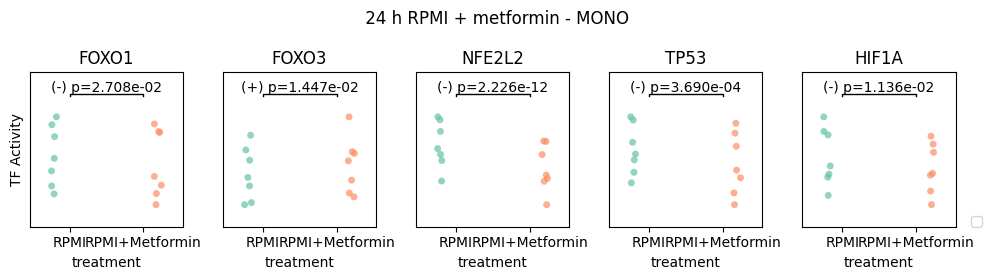

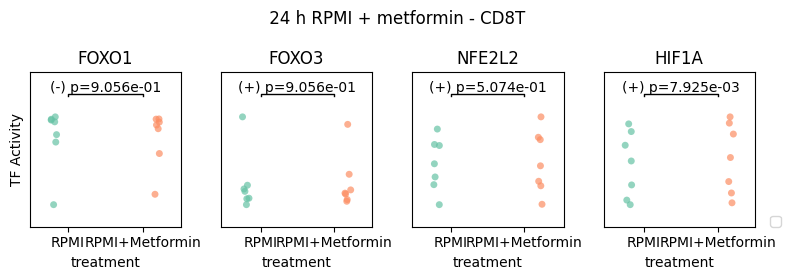

In [12]:
from ciim.src.tf_activity.plots import plot_ctr_condition_distribution

ctr = '24 h RPMI'
treatment = '24 h RPMI + metformin'

plot_ctr_condition_distribution(['MONO', 'CD8T'], features, treatment, ctr, dataset, type=type, feature_type=feature_type, 
                                map_names={'24 h LPS':'LPS', '24 h LPS + metformin':'LPS+Metformin',
                                             '24 h RPMI + metformin':'RPMI+Metformin', '24 h RPMI':'RPMI'}, 
                                stats=stats_all.rename(columns={'tf':'gene', 'target':'gene'}))

In [37]:
# stats_all_1 = stats_all[(stats_all['ctrl']=='24 h RPMI') & (stats_all['condition'].isin(['24 h RPMI + metformin', '24 h RPMI + metformin + ruxolitinib', '24 h RPMI + ruxolitinib']))] 
stats_all_2 = stats_all[stats_all['ctrl']=='24 h LPS']

stats_all_main = stats_all_2.copy()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


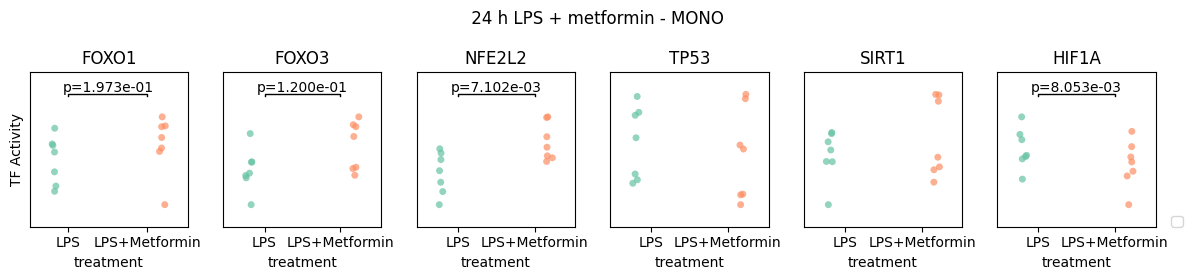

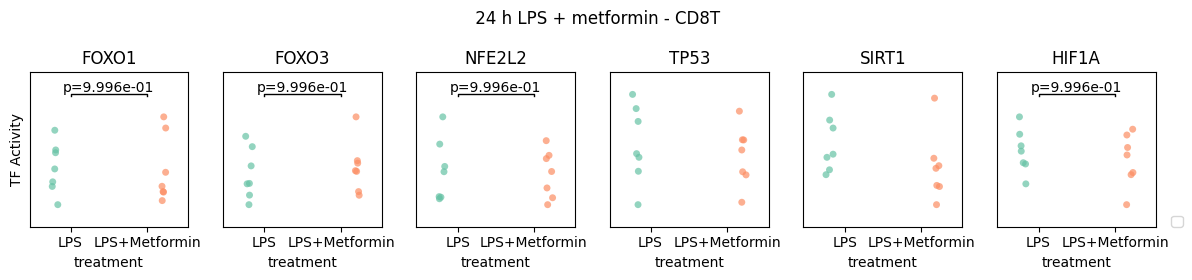

## Heatmap

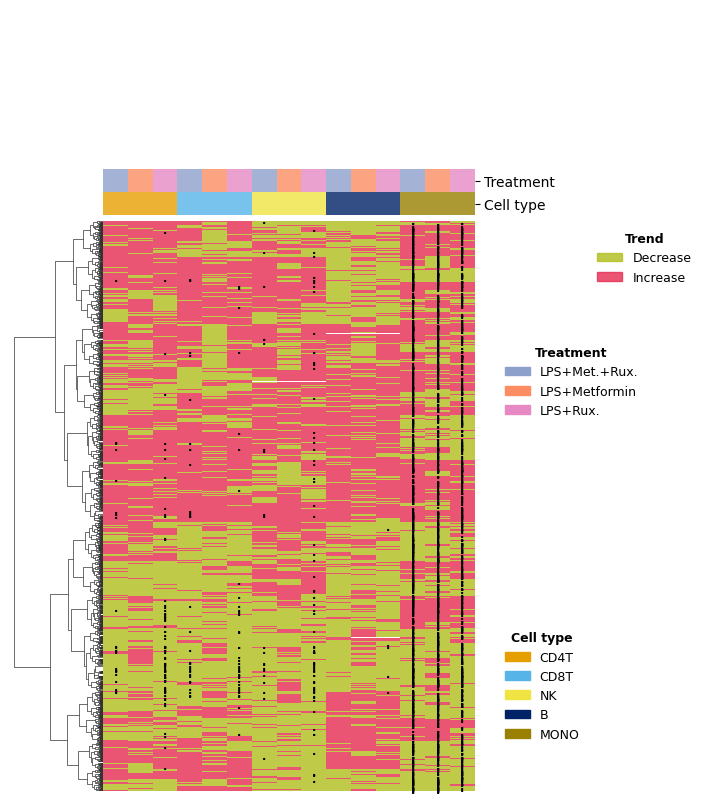

In [40]:
from ciim.src.tf_activity.plots import plot_overall_heatmap

stats_all_c = stats_all_main.copy()
pretty_names = {
    '24 h LPS': 'LPS',
    '24 h LPS + metformin': 'LPS+Metformin',
    '24 h LPS + metformin + ruxolitinib': 'LPS+Met.+Rux.', #Ruxolitinib
    '24 h LPS + ruxolitinib': 'LPS+Rux.',
    '24 h RPMI + metformin': 'RPMI+Metformin',
    '24 h RPMI + metformin + ruxolitinib': 'RPMI+Met.+Rux.',
    '24 h RPMI + ruxolitinib': 'RPMI+Rux.',
    # '24 h RPMI': 'RPMI',
    # '24 h rhCXCL9': 'rhCXCL9',
    # '24 h rhIFN-γ': 'rhIFN-γ'
}
stats_all_c['condition'] = stats_all_c['condition'].replace(pretty_names)
stats_all_c = stats_all_c[~stats_all_c['condition'].isna()]
stats_all_c = stats_all_c.rename(columns={'slope_condition': 'slope'})

stats_all_c['cell_type'] = pd.Categorical(stats_all_c['cell_type'], categories=cell_types, ordered=True)
stats_all_c['condition'] = stats_all_c['condition'].astype('category')

# stats_all_c['condition'] = pd.Categorical(stats_all_c['condition'], categories=pretty_names.values(), ordered=True)
stats_all_c['is_significant'] = stats_all_c['p_value_adj'] < 0.05
stats_all_c.rename(columns={'target': 'tf'}, inplace=True)
plot_overall_heatmap(stats_all_c, 
                    sig_dots_y_offset=4, 
                    first_col='cell_type',  first_col_palette=palette_cell_types,
                    second_col='condition', second_col_palette={value: color for value, color in zip(pretty_names.values(), sns.color_palette("Set2", n_colors=len(pretty_names.values())) )},
                    trend_colors = ['#B0BF1A', '#E52B50'],
                    trend_names = ['Decrease', 'Increase'],
                    bbox_to_anchor=(1.3, 1),
                    bbox_to_anchor_col1=(1.05, .3),
                    bbox_to_anchor_col2=(1.05, .8),
                    figsize=(6, 10),
                    map_names={**{'cell_type':'Cell type', 'condition': 'Treatment'}, **surrogate_names})
# plt.savefig(f'../output/tf_activity/overall_heatmap_{type}.png', bbox_inches='tight', dpi=300)

# Linearity analysis

In [2]:
adata_dict = {dataset:retrieve_adata(dataset) for dataset in datasets_all}

In [3]:
# - calculate corr
corr_results = {}
exp_results = {}
for cell_type in cell_types:
    exp_results[cell_type] = {}
    corr_results[cell_type] = {}
    for dataset in datasets_all:

        # - choose if gene expression or TF activity
        if False:
            adata = adata_dict[dataset]
            adata = adata[adata.obs['cell_type'] == cell_type].copy()
            adata.X = adata.X.todense()
        else:
            adata = retrieve_feature_data(dataset, cell_type, type='bulk')

        if adata.shape[0] < 2:
            continue

        expr_df = pd.DataFrame(adata.X, index=adata.obs.index, columns=adata.var_names)
        expr_df['age'] = adata.obs['age']
        expr_df = expr_df[(expr_df['age'] > 30) & (expr_df['age'] < 75)].copy()  # Filter out age ranges
        if True:
            expr_df['age_bin'] = (expr_df['age'].astype(int) // 5) * 5
            expr_df = expr_df.groupby('age_bin').mean().drop(columns='age').sort_index()
        else:
            expr_df = expr_df.set_index('age').sort_index()
        if expr_df.shape[0] < 2:
            continue

        corr = expr_df.T.corr(method='spearman')  # Correlation between age bins
        corr_results[cell_type][dataset] = corr
        exp_results[cell_type][dataset] = expr_df

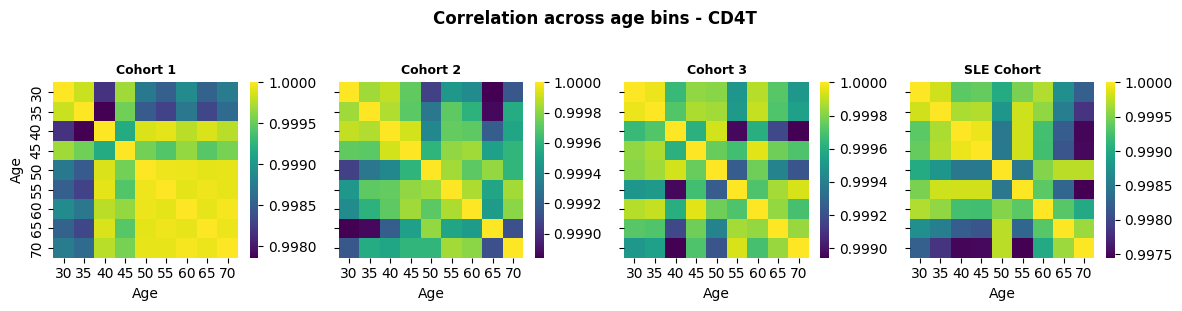

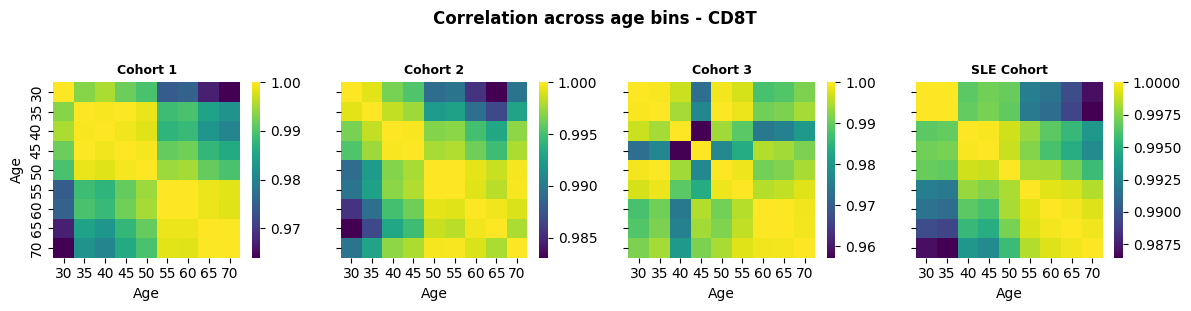

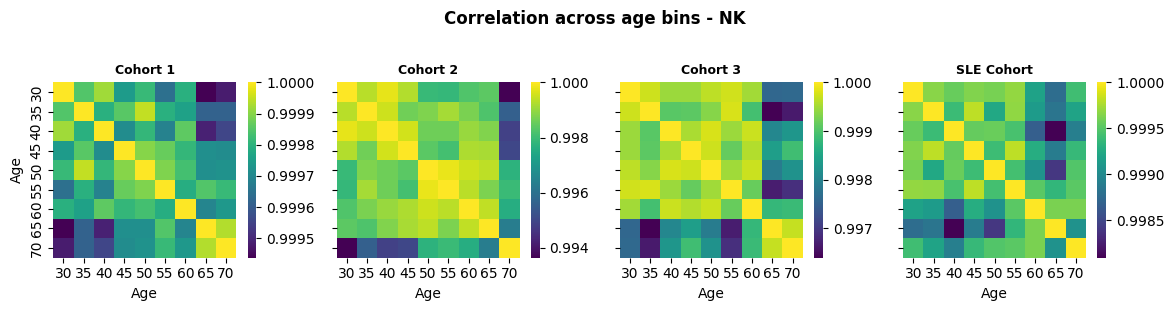

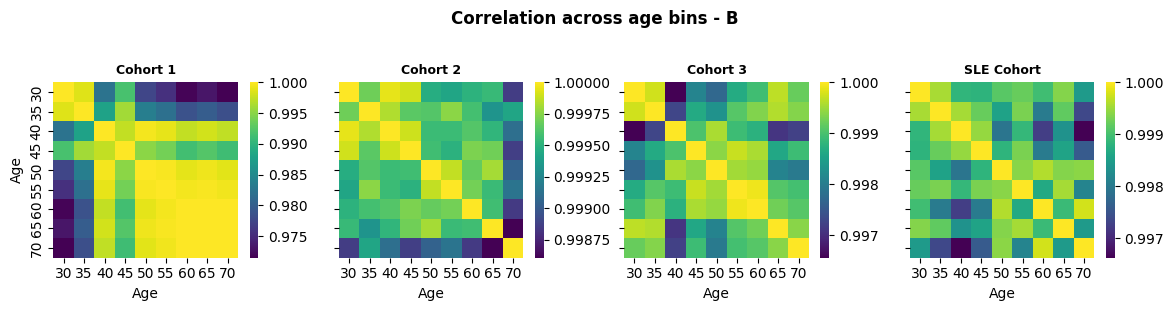

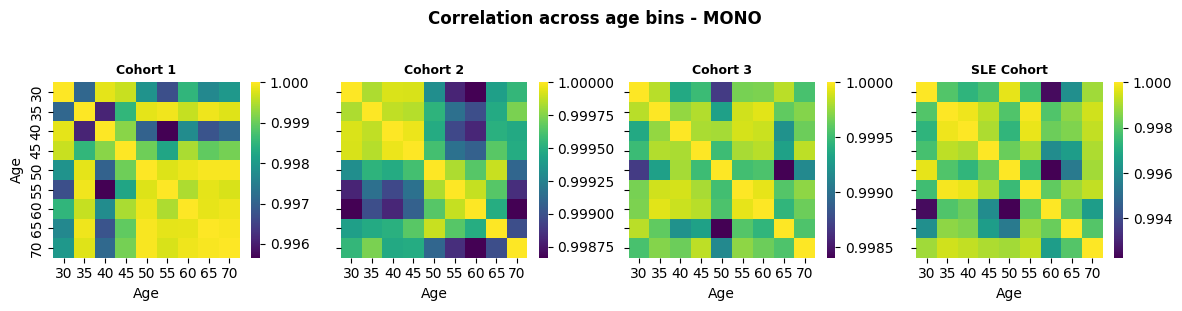

In [12]:
for cell_type, dataset_corrs in corr_results.items():
    datasets = [dataset for dataset in datasets_all if dataset!='data12']
    if not datasets:
        continue
    n_cols = len(datasets)
    n_rows = 1
    fig, axes = plt.subplots(1, len(datasets), figsize=(3 * n_cols, 3), sharey=True)
    fig.suptitle(f'Correlation across age bins - {cell_type}', fontsize=12, fontweight='bold', y=1.02)
    for i, dataset in enumerate(datasets):
        corr = dataset_corrs[dataset]
        ax = axes[i]
        
        sns.heatmap(corr, ax=ax, cmap='viridis')
        # sns.clustermap(corr, method='ward')
        ax.set_title(surrogate_names[dataset], fontsize=9, fontweight='bold')
        ax.set_xlabel('Age')
        if i == 0:
            ax.set_ylabel('Age')
        else:
            ax.set_ylabel('')

    plt.tight_layout()
    plt.show()

# Pseudo trajectory

In [4]:
from ciim.src.tf_activity.helper import run_pseudotime_analysis
sig_nets_bulk = pd.read_csv('../output/tf_activity/sig_nets_bulk.csv')

In [5]:
adata_dict = {}
for sub_type in ['Tcm_Naive_CD8', 'Tcm_Naive_CD4']:
    major_cell_type = mapping_minor_2_major[sub_type]
    adata_dict[sub_type] = {}
    for dataset in ['data1', 'data13']:
        adata = retrieve_feature_data(dataset, major_cell_type, type='bulk_minor')
        adata = adata[adata.obs['Sub_CT'] == sub_type].copy()
        net_sig = sig_nets_bulk[sig_nets_bulk['cell_type'] == major_cell_type] # - subset to only sig TFs
        adata = adata[:, adata.var_names.isin(net_sig['source'].unique())] 
        adata = run_pseudotime_analysis(adata)

        adata_dict[sub_type][dataset] = adata
        

Tcm_Naive_CD8 data1 SignificanceResult(statistic=0.15035098691069618, pvalue=5.424397466974495e-06)


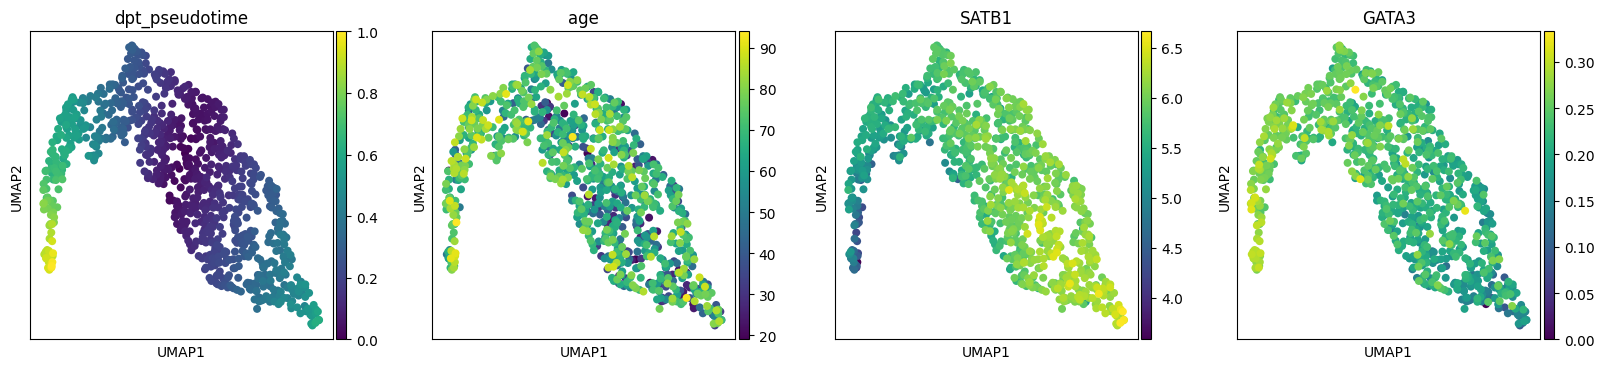

In [6]:
sub_type = 'Tcm_Naive_CD8'
dataset = 'data1'
adata = adata_dict[sub_type][dataset].copy()
print(sub_type, dataset, spearmanr(adata.obs['dpt_pseudotime'], adata.obs['age']))

# adata.obs.drop(columns='SATB1', inplace=True)
sc.pl.umap(adata, color=['dpt_pseudotime', 'age', 'SATB1', 'GATA3'])

computing velocity graph (using 1/56 cores)


  0%|          | 0/907 [00:00<?, ?cells/s]

Traceback (most recent call last):
  File "/home/jnourisa/miniconda3/envs/py10/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/jnourisa/miniconda3/envs/py10/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/jnourisa/miniconda3/envs/py10/lib/python3.10/multiprocessing/managers.py", line 599, in _run_server
    server.serve_forever()
  File "/home/jnourisa/miniconda3/envs/py10/lib/python3.10/multiprocessing/managers.py", line 184, in serve_forever
    sys.exit(0)
SystemExit: 0

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/jnourisa/miniconda3/envs/py10/lib/python3.10/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/home/jnourisa/miniconda3/envs/py10/lib/python3.10/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
  Fi

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


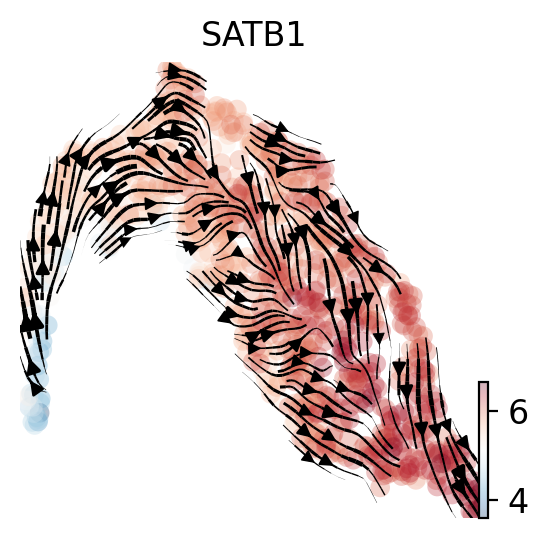

In [7]:
import scvelo as scv
import numpy as np
gene = 'SATB1'

scv.settings.set_figure_params('scvelo')

# Ensure neighbors are computed
adata.layers['spliced'] = adata.X.copy()  # Or use 'lognorm' layer if you prefer
sc.pp.neighbors(adata)

# Set UMAP if not already done
if 'X_umap' not in adata.obsm:
    sc.tl.umap(adata)

# Add the expression to a fake velocity layer
adata.layers['velocity'] = np.zeros_like(adata.X)
gene_idx = adata.var_names.get_loc(gene)
adata.layers['velocity'][:, gene_idx] = adata[:, gene].X.toarray().flatten() \
    if hasattr(adata[:, gene].X, 'toarray') else adata[:, gene].X.flatten()

# Optional: for coloring
adata.obs[gene] = adata[:, gene].X.toarray().flatten() \
    if hasattr(adata[:, gene].X, 'toarray') else adata[:, gene].X.flatten()

# Compute the fake embedding (required by scvelo)
scv.tl.velocity_graph(adata)

# Now you can plot
scv.pl.velocity_embedding_stream(adata, basis='umap', color=gene, size=200, figsize=(3,3),
    # , colorbar=False,
    legend_loc=(1.5, .2)
)

# In silico prediction

In [2]:
type = 'bulk' 
race = 'european'
cell_type = 'CD8T'
min_degree =2 # shared edges in nets
age_range = [20, 75]
# net = retrieve_net(dataset, cell_type)[['source', 'target', 'weight']]

In [6]:
def prepare_inputs(type, race, dataset, cell_type, min_degree, age_range=[20, 75]):
    from ciim.src.tf_activity.helper import get_consensus_net

    # - read inputs
    if False:
        stats_targets = pd.read_csv(f'../output/gene_expression/stats_all_{type}.csv')
        stats_sig = retrieve_sig_stats(type, race=race, filter_inconsistent=True).drop_duplicates(subset=['cell_type', 'tf'])
        stats_sig_target = stats_targets[(stats_targets['analysis'] == race) & (stats_targets['meta_p_adj'] < 0.05) & (stats_targets['trend']!= 'Inconsistent')].drop_duplicates(subset=['cell_type', 'target'])


        sig_tfs = stats_sig['tf'].unique()

        # - prepare the net
        sig_targets = stats_sig_target['target'].unique()
        net = get_consensus_net(datasets_e, cell_type, min_degree)
        net = net[net['source'].isin(sig_tfs)]
        net = net[net['target'].isin(sig_targets)]
        print(np.setdiff1d(stats_sig['tf'].unique(), net['source'].unique()))
    else:
        net = pd.read_csv(f'../output/sig_nets/sig_nets_{type}_{race}.csv')
        net = net[net['cell_type'] == cell_type].copy()
    

    # - convert net to a matrix (gene x tf)
    net_matrix = net.pivot(index='target', columns='source', values='weight').fillna(0)
    print(net_matrix.shape)

    # - prepare the expression data
    adata = retrieve_adata(dataset, type=type)
    adata = adata[~adata.obs['age'].isna()].copy()
    adata.obs['age'] = adata.obs['age'].astype(int)
    adata = adata[adata.obs['cell_type'] == cell_type].copy()

    # - bin 5 years and take the mean of the expression values
    expr_df = pd.DataFrame(adata.X.todense(), index=adata.obs.index, columns=adata.var_names)
    expr_df['age'] = adata.obs['age']
    expr_df = expr_df[(expr_df['age'] > age_range[0]) & (expr_df['age'] < age_range[1])].copy()  # Filter out age ranges
    expr_df['age_bin'] = (expr_df['age'].astype(int) // 5) * 5
    expr_df = expr_df.groupby('age_bin').mean().drop(columns='age')

    # - keep only those genes which are in both
    common_genes = net_matrix.index.intersection(expr_df.columns)
    net_matrix = net_matrix.loc[common_genes]
    expr_df = expr_df[common_genes]

    # - define variables for the simulation
    N = net_matrix.values # genes * tfs
    gs = expr_df.columns   # genes
    tfs = net_matrix.columns # tfs
    X0 = expr_df.iloc[0, :].values
    X_end = expr_df.iloc[-1, :].values
    max_delta = (expr_df.max() - expr_df.min()).values

    return N, gs, tfs, X0, X_end, max_delta, expr_df, net_matrix
# - run simulation
def run_simulation(N, X0, p, n_iter=10):
    X = X0.copy()
    X_store = []
    for it in range(n_iter):
        X = X + np.dot(N, p)
        X_store.append(X)
    Xs = np.array(X_store)
    return Xs
def combinatorial_experiments(N, X0, tfs, combinations=[1, 2]):
    import itertools
    results = []
    # loop over single and pairwise TF combinations
    for k in combinations:  # 1 = single, 2 = pairs
        for tf_combo in itertools.combinations(tfs, k):
            p = np.zeros_like(tfs, dtype=float)
            idxs = [np.where(tfs == tf)[0][0] for tf in tf_combo]
            for idx in idxs:
                p[idx] = max_delta[idx]  # or scale this as you like
            # run the simulation
            Xs = run_simulation(N, X0, p)
            X = Xs[-1]

            # measure impact
            rho, _ = spearmanr(X0, X)
            impact = 1 - rho  # higher = more change

            results.append({
                'TFs': tf_combo if k > 1 else tf_combo[0],
                'impact': impact,
                'num_TFs': k
            })

    # convert to DataFrame
    impact_df = pd.DataFrame(results)
    return impact_df

In [ ]:
# - run combinatorial experiments
impact_df_store = []
for dataset in datasets_e:
    N, gs, tfs, X0, X_end, max_delta, expr_df, net_matrix = prepare_inputs(type='bulk', race='european', dataset=dataset, cell_type='CD8T', min_degree=2)
    impact_df = combinatorial_experiments(N, X0, tfs, combinations=[1])
    impact_df = impact_df.sort_values('impact', ascending=False).head(10)
    impact_df['impact'] = impact_df['impact']/impact_df['impact'].max()
    impact_df['dataset'] = dataset
    impact_df_store.append(impact_df)
impact_df = pd.concat(impact_df_store)

(885, 55)
(885, 55)
(885, 55)
(885, 55)


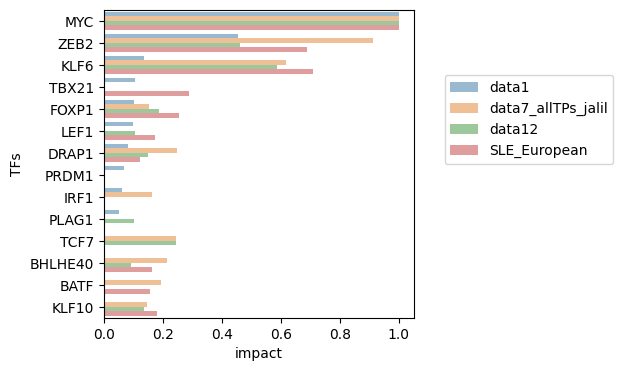

In [8]:
sns.barplot(data=impact_df, hue='dataset', y='TFs', x='impact', alpha=0.5)
plt.legend(loc=(1.1, .5))

In [51]:
# - check the corr between age groups
expr_df.T.corr().style.background_gradient(cmap='viridis', low=0, high=1, axis=1)

age_bin,20,25,30,35,40,45,50,55,60,65,70
age_bin,,,,,,,,,,,
20,1.000000,0.998972,0.998725,0.994626,0.995755,0.993996,0.993059,0.989181,0.989133,0.982304,0.978466
25,0.998972,1.000000,0.999137,0.995177,0.995917,0.994365,0.993382,0.989447,0.989375,0.982560,0.978714
30,0.998725,0.999137,1.000000,0.996481,0.997285,0.995897,0.995167,0.991776,0.991668,0.985672,0.982092
35,0.994626,0.995177,0.996481,1.000000,0.998584,0.999217,0.998978,0.997886,0.998003,0.994965,0.992978
40,0.995755,0.995917,0.997285,0.998584,1.000000,0.998898,0.998917,0.997250,0.997197,0.993587,0.991133
45,0.993996,0.994365,0.995897,0.999217,0.998898,1.000000,0.999415,0.998541,0.998600,0.995970,0.994102
50,0.993059,0.993382,0.995167,0.998978,0.998917,0.999415,1.000000,0.999099,0.999133,0.996863,0.995144
55,0.989181,0.989447,0.991776,0.997886,0.997250,0.998541,0.999099,1.000000,0.999721,0.998812,0.997702
60,0.989133,0.989375,0.991668,0.998003,0.997197,0.998600,0.999133,0.999721,1.000000,0.998894,0.997845


In [185]:
if False:
    # - create perturbation
    tf_case = 'BATF' # 'LEF1'
    tf_idx = np.where(tfs == tf_case)[0][0]
    p = np.zeros_like(tfs, dtype=float)  # or same shape as tfs
    p[tf_idx] = max_delta[tf_idx]

    
    X = run_simulation(N, X0, p, n_iter=10)

    # - evaluate the change 
    from scipy.stats import spearmanr
    from scipy.stats import pearsonr
    # print(f'Spearman (initial vs end X)', spearmanr(X0, X_end))
    print(f'Spearman (prediction vs initial X)', spearmanr(X0, X))
    # print(f'Spearman (prediction vs end X)', spearmanr(X_end, X))

Spearman (prediction vs initial X) SignificanceResult(statistic=0.789509389391522, pvalue=0.0)


# Disease

In [5]:
type = 'bulk'
stats_sig = retrieve_sig_stats(type).drop_duplicates(subset=['cell_type', 'tf'])
selected_cell_types = ['NK', 'CD8T', 'CD4T']

def retrieve_sle(type):
    dataset = 'SLE'
    stats_tfs = pd.read_csv(f'../output/tf_activity/stats_features_{type}.csv')
    stats_sle = stats_tfs[stats_tfs['dataset'].str.contains(dataset)].copy()
    stats_sle = stats_sle[stats_sle['p_value_adj'] < 0.05].copy()
    return stats_sle
stats_sle = retrieve_sle('bulk')

In [29]:


# Convert the entire column to arrays
stats_sle.groupby('cell_type').size().sort_values(ascending=False)

cell_type
CD8T    403
CD4T    275
MONO    212
B       147
NK      134
dtype: int64

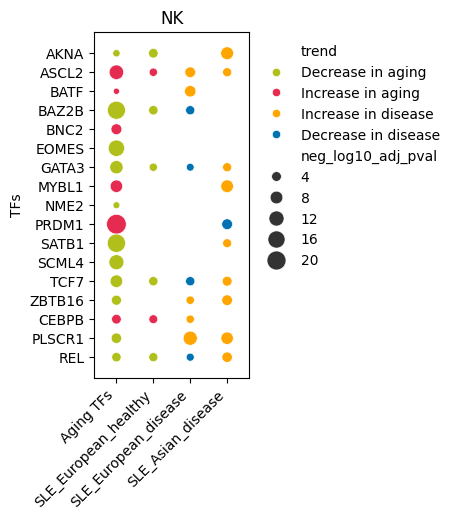

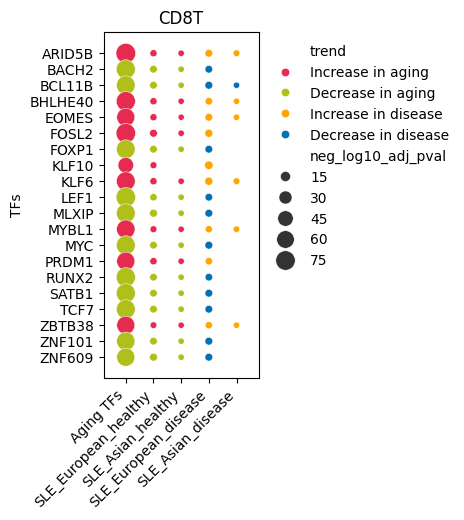

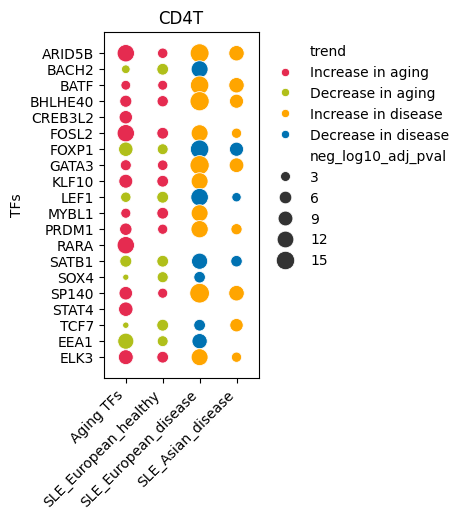

In [6]:
from ciim.src.common import palette_trend, palette_disease_effect
palette_all = {**palette_trend, **palette_disease_effect}

for cell_type in selected_cell_types:

    # - validation
    validation_df = stats_sig[stats_sig['cell_type']==cell_type]
    validation_df['analysis'] = 'Aging TFs'
    top_tfs = validation_df.sort_values('meta_p_adj').head(20)['tf'].unique() # change this to centrality

    # - aging
    stats_sotre = []
    for d in stats_sle['dataset'].unique():
        stats_h = stats_sle[(stats_sle['dataset'] == d) & (stats_sle['cell_type'] == cell_type) & (stats_sle['condition'] == 'healthy') & (~stats_sle['slope'].isna())].copy()
        stats_h['analysis'] = d + '_healthy'
        stats_h['trend'] = ['Increase in aging' if x > 0 else 'Decrease in aging' for x in stats_h['slope']]
        stats_sotre.append(stats_h)
    
    # - disease
    for d in stats_sle['dataset'].unique():
        stats_d = stats_sle[(stats_sle['dataset'] == d) & (stats_sle['cell_type'] == cell_type) & (stats_sle['condition'] == 'SLE') & (~stats_sle['slope_condition'].isna())].copy()

        stats_d['analysis'] = d + '_disease'
        stats_d['trend'] = ['Increase in disease' if x > 0 else 'Decrease in disease' for x in stats_d['slope_condition']]
        stats_sotre.append(stats_d)
    stats_a = pd.concat(stats_sotre)


    stats_combined = pd.concat([validation_df, stats_a])
    df = stats_combined[stats_combined['tf'].isin(top_tfs)]
    
    df['neg_log10_adj_pval'] = -np.log10(df['p_value_adj'])
    # df['dataset'] = df['dataset'].apply(lambda name: surrogate_names.get(name, name))


    fig, ax = plt.subplots(1, 1, figsize=(2, 4.5))
    sns.scatterplot(data=df, x='analysis', y='tf', hue='trend', ax=ax, palette=palette_all, size='neg_log10_adj_pval', sizes=(20, 200))
    ax.margins(x=.2, y=.07)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel('')
    ax.set_ylabel('TFs')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
    plt.title(f'{cell_type}')

1
1


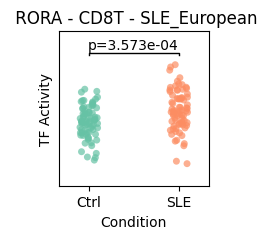

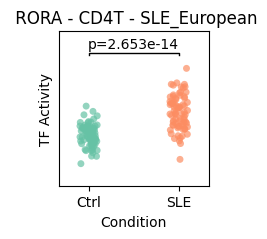

In [7]:
from ciim.src.tf_activity.plots import plot_tf_act_validation

palette_ctr_case = {name:color for name, color in zip(["Ctrl", "SLE"], sns.color_palette("Set2", 2))}

d = 'SLE_European'
case_tf = 'RORA'
stats_sle = retrieve_sle('bulk')
for cell_type in selected_cell_types:
    stats_df = stats_sle[(stats_sle['dataset'] == d) & (stats_sle['cell_type'] == cell_type) & (stats_sle['condition'] == 'SLE') & (~stats_sle['slope_condition'].isna())].copy()

    assert stats_df['slope_condition'].notna().all(), "Some values in 'slope_condition' are NaN"

    stats_df = stats_df[stats_df['tf']==case_tf].copy()
    if stats_df.shape[0] == 0:
        continue
    plot_tf_act_validation(stats_df, col1='values_control', col2='values_case', col1_name='Ctrl', col2_name='SLE', palette=palette_ctr_case)  
    plt.title(f' {case_tf} - {cell_type} - {d}')

# Case TFs

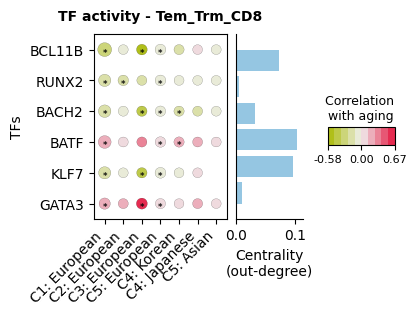

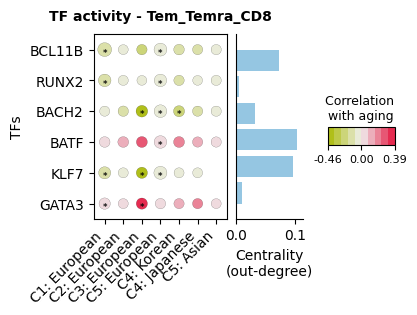

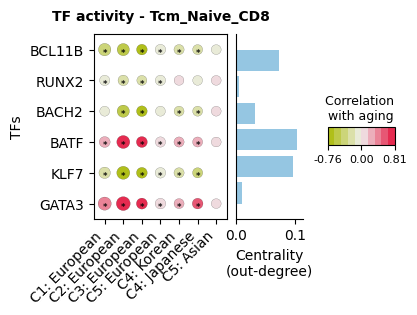

In [50]:
from ciim.src.tf_activity.plots import plot_features_vs_datasets

ttypes = ['Tem_Trm_CD8',
                'Tem_Temra_CD8',
                'Tcm_Naive_CD8']
features = ['BCL11B', 'RUNX2', 'BACH2', 'BATF', 'KLF7', 'GATA3']
type = 'bulk_minor'
for cell_type in ttypes:
    plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                feature_type='tf_activity', sizes=(50, 100), min_degree=1, filter_meta_significant=True)
# plt.savefig(f'../output/test.png', bbox_inches='tight', dpi=300)

In [2]:
case_tf = 'GATA3'  # 'TCF7' 'SATB1' 
type = 'bulk'
race = 'european'
n_top_targets = 10
selected_cell_types = ['CD8T', 'CD4T', 'NK'] #Tcm_Naive_CD8
n_panels = len(selected_cell_types)

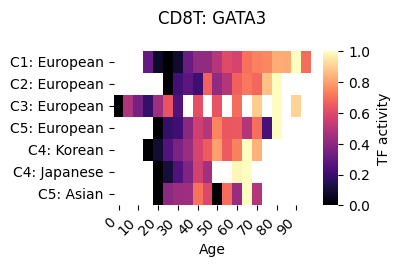

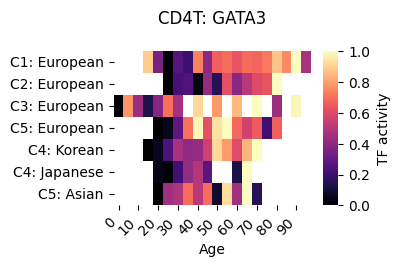

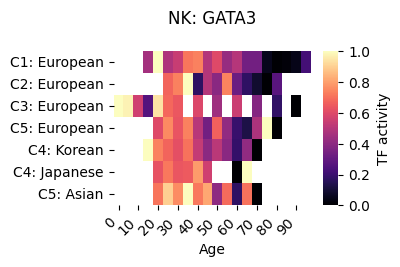

In [3]:
from ciim.src.tf_activity.plots import plot_feature_values_all_datasets

feature_type= 'tf_activity' # 'gene_expression'
for cell_type in selected_cell_types:
    plot_feature_values_all_datasets(cell_type, feature=case_tf, feature_type=feature_type, type=type, datasets=datasets_all, show_cbar=True)


In [4]:
nets_sig = pd.read_csv(f'../output/sig_nets/sig_nets_{type}_{race}.csv')
nets_sig = nets_sig[(nets_sig['source']==case_tf) & (nets_sig['cell_type'].isin(selected_cell_types))].copy()
n_targets = 10
if False:
    from ciim.src.tf_activity.plots import plot_net_nx
    
    for cell_type in selected_cell_types:
        net = nets_sig[(nets_sig['cell_type']==cell_type)]
        if True: # filter based on weight
            if net.shape[0]>n_targets:
                net = net.sort_values('weight', ascending=False, key=abs).head(n_targets)
        else: # targetted filter
            net = net[net['target'].isin(['FOS', 'FOSB', 'JUNB'])].copy()
        plot_net_nx(net, figsize=(4, 4))
        plt.tight_layout()
        plt.title(f'{case_tf} - {cell_type}', pad=10, fontsize=15, fontweight='bold')

In [5]:
stats_targets = retrieve_sig_stats(type, feature_type='gene_expression', race=race)

targets_store = []
for cell_type in selected_cell_types:
    net = nets_sig[nets_sig['cell_type']==cell_type]
    targets = net.sort_values('weight', ascending=False, key=abs).head(n_targets)['target'].unique()
    targets_store.append(targets)
all_targets = np.concatenate(targets_store)


def select_top_targets(cell_type, tf, n_top=30):
    net_store = []
    for dataset in datasets_all:
        net = retrieve_net(dataset, cell_type)
        net = net[(net['source']==tf) & (net['target'].isin(all_targets))].copy()
    
        #- select targets
        stats = stats_targets[(stats_targets['target'].isin(all_targets)) & (stats_targets['dataset']==dataset) & (stats_targets['cell_type']==cell_type)]
        net = net.merge(stats[['target', 'p_value_adj', 'slope']], on='target', how='left')
        net['neg_log10_adj_pval'] = -np.log10(net['p_value_adj'])
        net['dataset'] = dataset

        net_store.append(net)
    net_tf = pd.concat(net_store)
    return net_tf

net_store = []
for cell_type in selected_cell_types:
    net = select_top_targets(cell_type, case_tf, n_top=n_top_targets)
    net['cell_type'] = cell_type
    net_store.append(net)
net_tf = pd.concat(net_store)

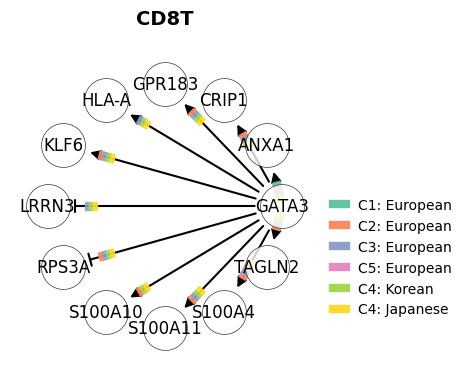

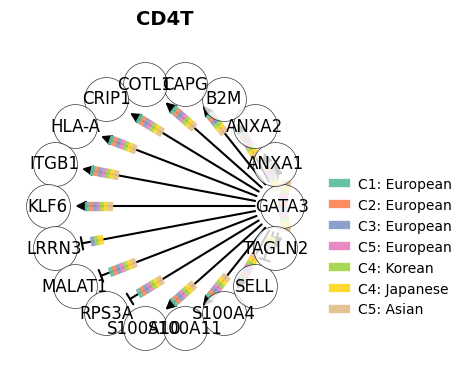

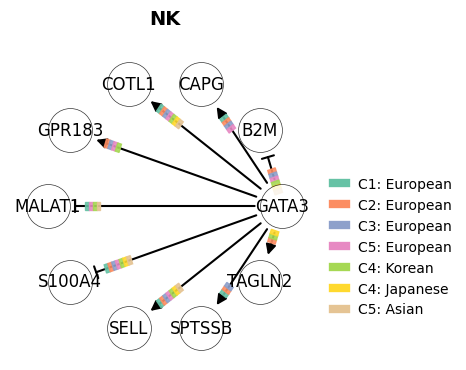

In [6]:
min_degree = 3 
draw_evidence = True
offset_evidence = .1
arc_offset = 0
figsize = (4, 4)
figsize_collectri = (4, 4)
offset_evidence_collectri = .1
for i, (cell_type) in enumerate(net_tf['cell_type'].unique()):

    net = net_tf[net_tf['cell_type'] == cell_type]
    features = net['target'].unique()

    # - keep edges with min degree
    net = net.groupby(['source', 'target']).filter(lambda x: len(x) >= min_degree)

    plot_net_nx(net, figsize=figsize, draw_evidence=draw_evidence, palette_evidence=palette_datasets, offset_evidence=offset_evidence, arc_offset=arc_offset)
    plt.title(f"{cell_type}", fontsize=14, pad=20, weight='bold')
    

In [7]:
net['dataset'].unique()

array(['data1', 'data7_allTPs_jalil', 'data12', 'SLE_European',
       'data13_Korean', 'data13_Japanese', 'SLE_Asian'], dtype=object)

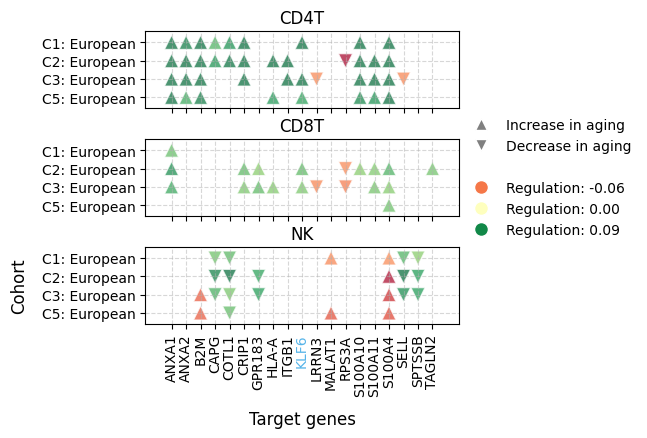

In [49]:
from ciim.src.tf_activity.plots import wrapper_flesh_out_tf_interactions, plot_tf_interactions_plus_target_stats

n_top_genes_per_dataset=10
# - select 
shared_state = net_tf.groupby(['cell_type','target'])['dataset'].nunique()
selected_tuple = shared_state[shared_state>=3].index
net_tf = net_tf.set_index(['cell_type', 'target']).loc[selected_tuple].reset_index()

n_targets = net_tf['target'].nunique()
net_tf['target'] = net_tf['target'].astype('category')
net_tf['dataset'] = pd.Categorical(net_tf['dataset'], categories=datasets_all, ordered=True)
fig, axes = plt.subplots(n_panels, 1, figsize=(n_targets*.16 +1, len(datasets_all)*.4 + 1), sharex=True)
for i, (cell_type) in enumerate(net_tf['cell_type'].unique()):
    ax = axes[i] if n_panels > 1 else axes
    if i == 1:
        show_legend = True
    else:
        show_legend = False
    net = net_tf[net_tf['cell_type'] == cell_type]   
    net = net[net['neg_log10_adj_pval'] > 1.4]
    
    # wrapper_flesh_out_tf_interactions(datasets_all, cell_type, tf=case_tf, type=type, n_top=n_top_genes_per_dataset, keep_sig_only=True, sizes=(50, 200), ax=ax, show_legend=show_legend)
    plot_tf_interactions_plus_target_stats(net.copy(), ax=ax, show_legend=show_legend, sizes=(50, 200), annotate_sig=False, annotate_targets=True)

    ax.margins(y=0.2, x=0.1)
    ax.set_title(cell_type)
    ax.set_xlabel('Target genes')
    ax.grid(True, linestyle='--', alpha=0.5)
    if i != n_panels - 1:
        ax.set_ylabel('')

plt.subplots_adjust(hspace=0.4)
# plt.suptitle(f'Targets of {tf}')

In [38]:
# tf_all = np.loadtxt(f"/vol/projects/jnourisa/prior/tf_all.csv", dtype=str)
# 'ANXA1' in tf_all

False

In [9]:
from ciim.src.tf_activity.plots import plot_net_nx, heatplot_age_trend, plot_net_nx_consensus
from ciim.src.tf_activity.helper import binarize_expression

def wrapper_plot_targets_all(nets_sig, n_top=10):
    for i, cell_type in enumerate(nets_sig['cell_type'].unique()):
        net = nets_sig[nets_sig['cell_type'] == cell_type]
        net = net.sort_values('weight', ascending=False, key=abs).head(n_top)

        # - keep those that are at least in three datasets 
        top_targets = net['target'].unique()
        
        if False: # network plot
            plot_net_nx(net, figsize=(5,4))
            # plt.title(cell_type, fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()

        if True: # target trend plot
            plot_targets_expression_for_datasets(cell_type, type=type, top_targets=top_targets)
if True:
    wrapper_plot_targets_all(nets_sig, n_top=10)

ImportError: cannot import name 'plot_net_nx_consensus' from 'ciim.src.tf_activity.plots' (/home/jnourisa/projs/ongoing/ciim/src/tf_activity/plots.py)

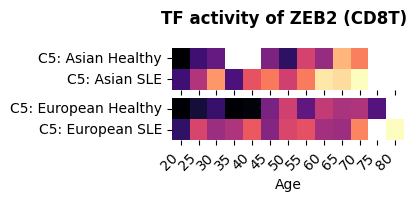

In [14]:
from ciim.src.tf_activity.plots import heatplot_age_trend
from collections import defaultdict
from ciim.src.common import surrogate_names


def format_tf_activity_for_disease_trend_plot(dataset, cell_type, tf):
    tf_acts = retrieve_feature_data(dataset, cell_type, type='bulk')
    tf_acts = tf_acts[:, tf_acts.var_names == tf]
    if tf_acts.shape[1]==0:
        return None

    expr = tf_acts.to_df()
    expr = expr.merge(tf_acts.obs[['age', 'disease']], left_index=True, right_index=True, how='left')
    expr['disease'] = expr['disease'].astype('category')
    expr['age'] = expr['age'].astype(int)

    # Pivot table: rows = disease, columns = age, values = expression
    expr_table = expr.pivot_table(index='disease', columns='age', values=tf)

    # Bin ages into 5-year intervals
    df = expr_table.copy()
    age_columns = df.columns
    age_bins = defaultdict(list)

    for col in age_columns:
        bin_start = (col // 5) * 5
        age_bins[bin_start].append(col)

    # Average across bins
    binned_means = {bin_start: df[bin_ages].mean(axis=1) for bin_start, bin_ages in age_bins.items()}
    binned_df = pd.DataFrame(binned_means)

    # Sort bins by age
    binned_df = binned_df[sorted(binned_df.columns)]
    
    return binned_df


for i, cell_type in enumerate(selected_cell_types):
    fig, axes = plt.subplots(2, 1, figsize=(3, 1.2), sharey=False, sharex=True)
    
    df_store = []
    for j, dataset in enumerate(['SLE_Asian', 'SLE_European']):
        ax = axes[j]
        binned_df = format_tf_activity_for_disease_trend_plot(dataset, cell_type, tf=case_tf)
        if binned_df is None:
            continue
        binned_df.index = [f'{dataset}_{index}' for index in binned_df.index]
        
        binned_df.index = binned_df.index.astype(str)
        
        binned_df.index = [surrogate_names.get(name, name) for name in binned_df.index]
        if i == len(axes)-1:
            show_cbar = True
        else:   
            show_cbar = False
        
        heatplot_age_trend(binned_df, cmap='magma', cbar_title="TF activity", y_label="Condition", ax=ax, show_cbar=show_cbar, shrink=1)
        if i == 0:
            ax.set_ylabel('')
        else:
            ax.set_ylabel('')
        if j == 0:
            # ax.set_title(cell_type, pad=10, fontsize=10, fontweight='bold')
            ax.set_xlabel('')
        else:
            ax.set_xlabel('Age')
        
    plt.suptitle(f'TF activity of {case_tf} ({cell_type})', fontsize=12, fontweight='bold', y=1.2)

In [15]:
dataset = 'SLE_European'

# - plot target gene expression trend    
adata_all = retrieve_adata(dataset)
for cell_type in ['CD8T', 'CD4T', 'NK']:
    net = net_dict[cell_type]
    # - remove those with conflicting slopes across datasets
    slope_signs = net.pivot(index='target', columns='dataset', values='slope').apply(np.sign)
    mask = slope_signs.sum(axis=1).abs() == len(datasets_all)
    consistent_targets = slope_signs[mask].index
    net = net[net['target'].isin(consistent_targets)]
    # - keep those that are at least in three datasets 
    top_targets = net.groupby(['target'])['dataset'].nunique().sort_values(ascending=False)
    top_targets = top_targets[top_targets==len(datasets_all)].head(10).index

    
    # - get the expression 
    adata = adata_all[adata_all.obs['cell_type'] == cell_type]
    adata = adata[:, adata.var_names.isin(top_targets)]
    # - binarize and mean
    expr = adata.to_df()
    expr = expr.merge(adata.obs[['age', 'disease']], left_index=True, right_index=True, how='left')
    expr = expr.sort_values('age')
    expr['age_bin'] = (expr['age'].astype(int) // 5) * 5
    expr.drop(columns=['age'], inplace=True)
    mean_expr_all = expr.groupby(['age_bin', 'disease']).mean().reset_index()
    n_groups = len(mean_expr_all['disease'].unique())

    fig, axes = plt.subplots(1, n_groups, figsize=(3*n_groups, .3*len(top_targets)), sharey=False)
    for i, disease in enumerate(mean_expr_all['disease'].unique()):
        ax = axes[i]
        mean_expr = mean_expr_all[mean_expr_all['disease'] == disease].set_index('age_bin').drop(columns=['disease']).T
        if i == 0:
            # Normalize expression
            min_vals = mean_expr.min(axis=1)
            max_vals = mean_expr.max(axis=1)
            show_cbar = False
        else:
            show_cbar = True
    
        mean_expr = (mean_expr.sub(min_vals, axis=0)).div(max_vals - min_vals, axis=0)
        if mean_expr.shape[0] ==0 :
            print(f'No expression for {cell_type} {disease}')
            continue

        if i == 0:
            from sklearn.cluster import KMeans
            if len(mean_expr) > 2:
                kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
                clusters = kmeans.fit_predict(mean_expr.fillna(0))
                mean_expr['cluster'] = clusters
                mean_expr = mean_expr.sort_values('cluster').drop(columns=['cluster'])
            ordered_targets = mean_expr.index
        else:
            mean_expr = mean_expr.loc[ordered_targets]
        heatplot_age_trend(mean_expr, cmap='viridis', cbar_title="Gene expression", y_label="Targets", ax=ax, show_cbar=show_cbar)
        if i != 0:
            ax.set_ylabel('')
            ax.set_yticklabels([])
        ax.set_xlabel('Age')
        ax.set_title(surrogate_names[disease], pad=10, fontsize=10, fontweight='bold')

    plt.suptitle(f"{cell_type} ({dataset.split('_')[1]})", fontsize=12, fontweight='bold', y=1.05)
# plt.tight_layout()

NameError: name 'net_dict' is not defined

In [6]:
# retrieve_feature_data(dataset, cell_type, type='bulk_minor').obs

## Sub types

In [ ]:
from ciim.src.tf_activity.plots import heatplot_age_trend

def format_tf_activity_for_minor_plot(tf, subtype, datasets):
    cell_type = mapping_minor_2_major[subtype]
    tf_acts_store = []
    for dataset in datasets:
        tf_acts = retrieve_feature_data(dataset, cell_type, type='bulk_minor')
        tf_acts = tf_acts[tf_acts.obs['Sub_CT'] == subtype]
        tf_acts = tf_acts[:, tf_acts.var_names==tf]
        tf_acts.obs['dataset'] = dataset
        tf_acts_store.append(tf_acts)
    tf_acts = ad.concat(tf_acts_store)
    expr = tf_acts.to_df()
    expr = expr.merge(tf_acts.obs[['age', 'dataset']], left_index=True, right_index=True, how='left')

    expr['dataset'] = expr['dataset'].astype('category')
    expr['age'] = expr['age'].astype('category')

    # - convert it to index (condition) vs columns (age)
    expr_table = expr.pivot_table(index='dataset', columns='age', values=tf)
    expr_table.columns = expr_table.columns.astype(int)
    # - binarize the age
    df = expr_table.copy()
    age_columns = df.columns
    age_bins = {}
    for col in age_columns:
        bin_start = (col // 5) * 5  # Determine the bin start
        if bin_start not in age_bins:
            age_bins[bin_start] = []  # Initialize the list if the bin is not yet in the dictionary
        age_bins[bin_start].append(col)
    binned_means = {}
    for bin_start, bin_ages in age_bins.items():
        binned_means[bin_start] = df[bin_ages].mean(axis=1)

    expr_mean = pd.DataFrame(binned_means)
    min_vals = expr_mean.min(axis=1)
    max_vals = expr_mean.max(axis=1)
    expr_mean = (expr_mean.sub(min_vals, axis=0)).div(max_vals - min_vals, axis=0)
    return expr_mean

#     # - binarize 
#     if True: 
#         expr = adata.to_df()
#         expr = expr.merge(adata.obs[['age']], left_index=True, right_index=True, how='left').set_index('age')
#         # expr = expr[expr.index>10]
#         expr.sort_index(inplace=True)
#         expr['age_bin'] = (expr.index.astype(int) // 5) * 5
#         expr_mean = expr.groupby('age_bin').mean().T
#     # Normalize expression
#     min_vals = expr_mean.min(axis=1)
#     max_vals = expr_mean.max(axis=1)
#     expr_mean = (expr_mean.sub(min_vals, axis=0)).div(max_vals - min_vals, axis=0)
#     return expr_mean

for j, cell_type in enumerate(['CD8T', 'CD4T', 'NK']):
    subtypes = mapping_major_2_minor[cell_type]
    fig, axes = plt.subplots(1, len(subtypes), figsize=(3*len(subtypes), 1.5), sharey=True)

    for i, subtype in enumerate(subtypes):
        ax = axes[i]
        binned_df = format_tf_activity_for_minor_plot(case_tf, subtype=subtype, datasets=datasets_all)

        binned_df.index = binned_df.index.astype(str)
        binned_df = binned_df.reindex(datasets_all)
        binned_df.index = binned_df.index.map(lambda name: surrogate_names.get(name, name))

        if i == len(axes)-1:
            show_cbar = True
        else:   
            show_cbar = False
        
        heatplot_age_trend(binned_df, cmap='magma', cbar_title="TF activity", y_label="Condition", ax=ax, show_cbar=show_cbar, shrink=1)
        if i == 0:
            ax.set_ylabel('Cell type')
        else:
            ax.set_ylabel('')
        ax.set_xlabel('Age')
        ax.set_title(subtype, pad=10, fontsize=10, fontweight='bold')
    plt.suptitle(f'TF activity trend of {case_tf} ({cell_type})', fontsize=12, fontweight='bold', y=1.3)